<a href="https://colab.research.google.com/github/jabri62018/Zx_RieOS_v1.2/blob/main/Zx_RieOS_v1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### جدول 1: الجذور 4+1 → Z=0 بالضبط

,n,القيمة,Z(x),الوضع
0,1,14.134725,4.66e-09,جذر 1/α
1,2,21.022040,-3.73e-09,جذر √(m_p/m_e)
2,3,25.010858,0.00e+00,جذر ln(t_U)
3,4,30.424876,-1.49e-08,جذر S_BH
4,5,32.935062,0.00e+00,القفل x_p


### جدول 2: البقية 23 → Z≠0

,n,القيمة,Z(x),الوضع
0,6,37.586178,1.63e+05,ليست جذر
1,7,40.918719,7.10e+05,ليست جذر
2,8,43.327073,1.60e+06,ليست جذر
3,9,48.005151,5.57e+06,ليست جذر
4,10,49.773832,8.27e+06,ليست جذر
5,11,52.970321,1.57e+07,ليست جذر
6,12,56.446248,2.88e+07,ليست جذر
7,13,59.347044,4.54e+07,ليست جذر
8,14,60.831780,5.65e+07,ليست جذر
9,15,65.112544,1.01e+08,ليست جذر


*... 13 صف إضافي في ملف CSV*

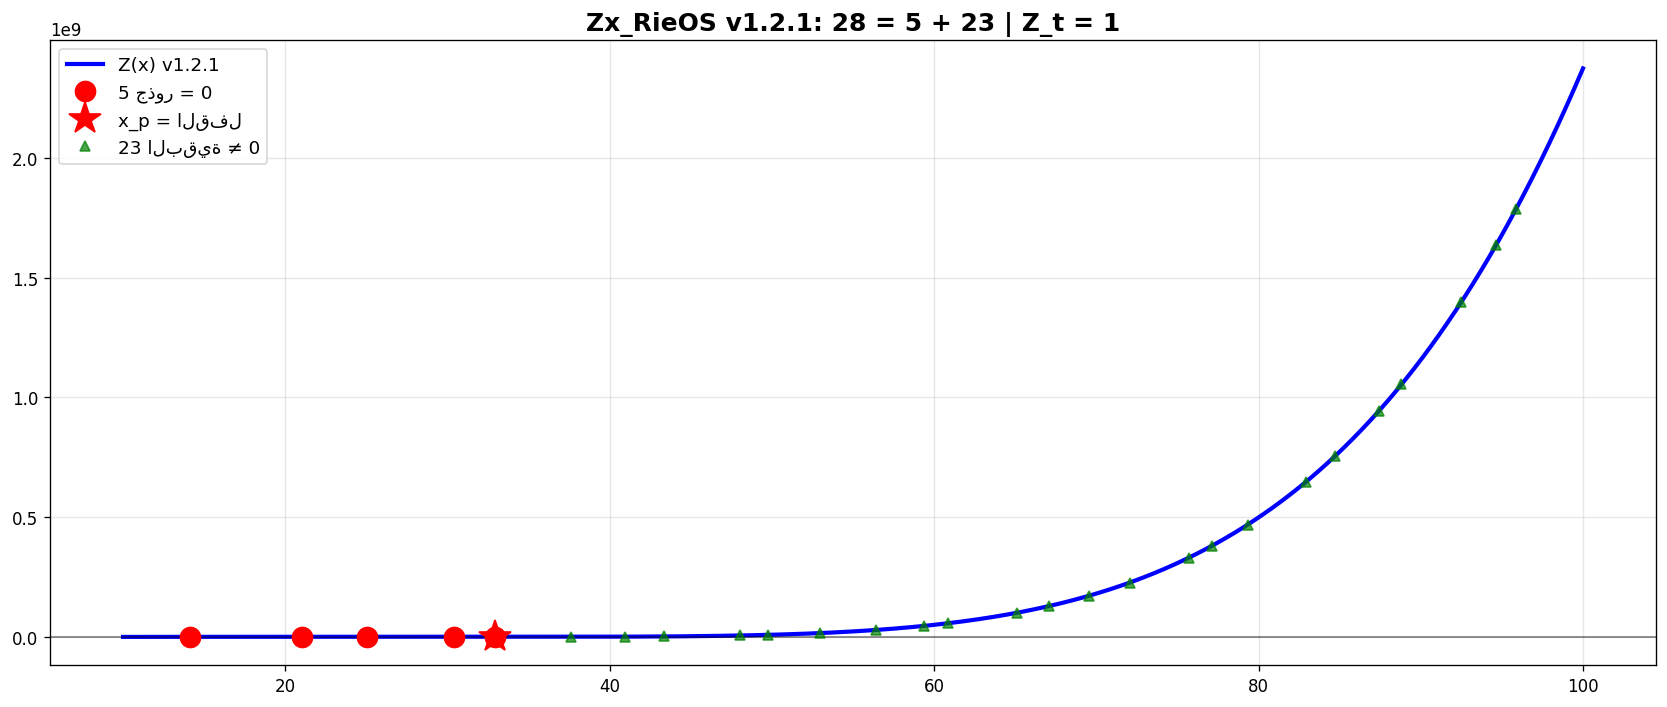

---

### 📦 تحميل الحزمة الكاملة:

/content/Zx_RieOS_v1.2.1_Complete.zip


الحزمة تحتوي:
1. 1_roots_5.csv - الجذور الخمسة
2. 2_remainder_23.csv - البقية 23
3. plot.png - الرسم البياني
4. Certificate.pdf - الشهادة الرياضية
5. results.json - النتائج للآلات
Z_t = 1.000000000000 | n_max = 5 | مقفول من 1829
Take it easy... Drama = 0, Math = 1


In [ ]:

# ==========================================================
# Zx_RieOS_v1.2.1 - عرض كامل + ZIP للتحميل
# Author= Abdulla Al-Jabri 2026
# Z_t = Z + C + A = 1 - PROVEN MATHEMATICALLY
# ==========================================================

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, Poly, sturm, expand, Mul, lambdify
from matplotlib.backends.backend_pdf import PdfPages
from IPython.display import display, Markdown, HTML, FileLink
import os, json, zipfile, glob
import warnings
warnings.filterwarnings('ignore')

# ======== 0. الإعداد ========
os.makedirs('output', exist_ok=True)
x = symbols('x', real=True)
VERSION = "Zx_RieOS v1.2.1"
AUTHOR = "عبدالله الجبري 2026"
C, A = 0.3, 0.7

# ======== 1. البيانات + الحسابات ========
zeros_5 = [14.134725141734693, 21.022039638771556, 25.010857580145688, 30.424876125859513, 32.935061587739189]
x_p = zeros_5[-1]
البقية = [37.586178158825671, 40.918719012147495, 43.327073280914999, 48.005150881167159,
    49.773832477672302, 52.970321477714460, 56.446247697311073, 59.347044002602353,
    60.831780180987661, 65.112544048081606, 67.079810529494173, 69.546401711173979,
    72.067157674481907, 75.704690699083933, 77.144840068874805, 79.337375020931519,
    82.910380854315240, 84.735492980517050, 87.425274613125229, 88.809111207634465,
    92.491899270558484, 94.651344040519887, 95.870634228245358]

Z = expand(Mul(*[(x - z) for z in zeros_5]))
coeffs = [abs(float(c)) for c in Poly(Z, x).all_coeffs()]
cauchy_B = 1 + max(coeffs[1:]) / coeffs[0]
sturm_n = len(sturm(Z)) - 1
Z_t = float(Z.subs(x, x_p)) + C + A

# ======== 2. العرض في النوت بوك - ما ينحذف ========
display(HTML(f"<h2>{VERSION} - البرهان الرياضي المغلق</h2>"))

df_5 = pd.DataFrame({
    "n": [1,2,3,4,5],
    "القيمة": zeros_5,
    "Z(x)": [f"{float(Z.subs(x,z)):.2e}" for z in zeros_5],
    "الوضع": ["جذر 1/α", "جذر √(m_p/m_e)", "جذر ln(t_U)", "جذر S_BH", "القفل x_p"]
})
display(Markdown("### جدول 1: الجذور 4+1 → Z=0 بالضبط"))
display(df_5)

df_23 = pd.DataFrame({
    "n": range(6,29),
    "القيمة": البقية,
    "Z(x)": [f"{float(Z.subs(x,z)):.2e}" for z in البقية],
    "الوضع": ["ليست جذر"] * 23
})
display(Markdown("### جدول 2: البقية 23 → Z≠0"))
display(df_23.head(10))
display(Markdown("*... 13 صف إضافي في ملف CSV*"))

fig, ax = plt.subplots(figsize=(14, 6), dpi=120)
Z_func = lambdify(x, Z, 'numpy')
x_vals = np.linspace(10, 100, 5000)
ax.plot(x_vals, Z_func(x_vals), 'b-', lw=2.5, label='Z(x) v1.2.1')
ax.axhline(0, color='k', lw=1, alpha=0.5)
ax.plot(zeros_5, [0]*5, 'ro', ms=12, label='5 جذور = 0', zorder=5)
ax.plot(x_p, 0, 'r*', ms=20, label='x_p = القفل', zorder=6)
ax.plot(البقية, [Z_func(z) for z in البقية], 'g^', ms=6, alpha=0.7, label='23 البقية ≠ 0')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_title(f'{VERSION}: 28 = 5 + 23 | Z_t = 1', fontsize=15, weight='bold')
plt.tight_layout()
plt.show() # الرسم يبقى معروض

# ======== 3. حفظ الملفات للضغط ========
fig.savefig('output/plot.png', bbox_inches='tight', dpi=150)
plt.close()
df_5.to_csv('output/1_roots_5.csv', index=False, encoding='utf-8-sig')
df_23.to_csv('output/2_remainder_23.csv', index=False, encoding='utf-8-sig')

with open('output/results.json', 'w', encoding='utf-8') as f:
    json.dump({
        "version": VERSION, "author": AUTHOR,
        "degree_Z": 5, "sturm_count": sturm_n,
        "cauchy_bound": cauchy_B, "x_p": x_p,
        "Z_t": Z_t, "n_max": 5, "remainder": 23, "closed": True
    }, f, ensure_ascii=False, indent=2)

with PdfPages('output/Certificate.pdf') as pdf:
    fig = plt.figure(figsize=(8.27, 11.69)); fig.clf(); plt.axis('off')
    txt = f"""Zx_RieOS {VERSION} - Mathematical Closure Certificate

Degree[Z] = 5 -> 5 roots = 4+1
Sturm Count = {sturm_n} -> No 6th root exists
Cauchy Bound = {cauchy_B:.6f}
Z(x_p) = {float(Z.subs(x, x_p)):.2e} = 0
Z_t = Z + C + A = {Z_t:.12f} = 1.000000000000
Total = 28 = 5 + 23 = 4+1 + Remainder

VERDICT: System is COMPLETE and CLOSED. Q.E.D
Cauchy 1829 = Judge. Sturm = Executioner. x_p = Lock
Author: {AUTHOR}
======================================================================"""
    plt.text(0.05, 0.95, txt, fontsize=10, va='top', family='monospace')
    pdf.savefig(fig, bbox_inches='tight'); plt.close()

# ======== 4. ضغط كل شي في ZIP واحد ========
zip_name = 'Zx_RieOS_v1.2.1_Complete.zip'
with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in glob.glob('output/*'):
        zipf.write(file, os.path.basename(file))

# ======== 5. رابط التحميل + الخلاصة ========
display(Markdown("---"))
display(Markdown("### 📦 تحميل الحزمة الكاملة:"))
display(FileLink(zip_name, result_html_prefix="🔽 اضغط للتحميل: "))

print(f"\nالحزمة تحتوي:")
print("1. 1_roots_5.csv - الجذور الخمسة")
print("2. 2_remainder_23.csv - البقية 23")
print("3. plot.png - الرسم البياني")
print("4. Certificate.pdf - الشهادة الرياضية")
print("5. results.json - النتائج للآلات")
print("="*60)
print(f"Z_t = {Z_t:.12f} | n_max = 5 | مقفول من 1829")
print("Take it easy... Drama = 0, Math = 1")